In [2]:
import pandas as pd

new_data_df = pd.read_csv('new-data.csv')
engineered_data_df = pd.read_csv('engineered_data.csv')
new_data_df.head(), engineered_data_df.head()

(             timestamp     open    high     low     close   volume
 0  2025-04-25 20:00:00  550.640  550.64  550.64  550.6400  1571349
 1  2025-04-25 19:45:00  551.100  551.25  551.06  551.2293    16162
 2  2025-04-25 19:30:00  551.125  551.17  550.70  551.1200     7317
 3  2025-04-25 19:15:00  551.080  551.15  550.99  551.1090     8679
 4  2025-04-25 19:00:00  551.140  551.15  550.85  551.0600     7862,
                     datetime      open      high       low     close  volume  \
 0  2025-03-13 00:00:00-04:00  554.9616  554.9616  553.4960  553.8948   24154   
 1  2025-03-13 00:15:00-04:00  553.9746  554.5827  553.0573  554.5129   33800   
 2  2025-03-13 00:30:00-04:00  554.5129  554.6326  553.9546  554.4033    7404   
 3  2025-03-13 00:45:00-04:00  554.4132  555.0912  554.3434  555.0314    5571   
 4  2025-03-13 01:00:00-04:00  555.0214  555.4302  554.3036  555.4003   24140   
 
    Prev_High  Prev_Low  London_High  London_Low  swept_Prev_High  \
 0        NaN       NaN     566.94

In [3]:
# Remove timezone information by converting to naive datetimes (local time without timezone)
new_data_df['timestamp'] = pd.to_datetime(new_data_df['timestamp']).dt.tz_localize(None)
engineered_data_df['datetime'] = pd.to_datetime(engineered_data_df['datetime']).dt.tz_localize(None)

# Now try merging the datasets again
merged_df = pd.merge_asof(new_data_df.sort_values('timestamp'), 
                           engineered_data_df.sort_values('datetime'), 
                           left_on='timestamp', right_on='datetime', 
                           direction='backward')

# Show the merged data
merged_df.head()


,timestamp,open_x,high_x,low_x,close_x,volume_x,datetime,open_y,high_y,low_y,...,London_Low,swept_Prev_High,swept_Prev_Low,gap_up,gap_down,broke_Asia_High,broke_Asia_Low,London_Bias,NY_Position_vs_London,London_Momentum
0,2025-03-27 04:00:00,568.00,568.89,567.23,567.70,32117,2025-03-27 04:00:00,568.5077,570.000,567.2490,...,564.94,False,False,False,False,False,False,up,-1.05,0.000405
1,2025-03-27 04:15:00,567.70,568.46,567.70,568.42,21858,2025-03-27 04:15:00,568.2850,568.400,567.8600,...,564.94,False,False,False,False,False,False,up,-1.05,0.000405
2,2025-03-27 04:30:00,568.48,568.95,568.42,568.65,19445,2025-03-27 04:30:00,568.1000,568.980,568.0109,...,564.94,False,False,False,False,False,False,up,-1.05,0.000405
3,2025-03-27 04:45:00,568.65,569.32,568.26,569.32,9714,2025-03-27 04:45:00,568.2910,568.590,567.9100,...,564.94,False,False,False,False,False,False,up,-1.05,0.000405
4,2025-03-27 05:00:00,569.33,569.37,568.87,569.10,8300,2025-03-27 05:00:00,568.1300,577.305,567.6300,...,564.94,False,False,False,False,False,False,up,-1.05,0.000405


In [4]:
# Define a function to check if price has taken out the hourly high or low
def check_liquidity_sweep(row):
    if row['high_x'] > row['London_High']:
        return 'Sweep High'
    elif row['low_x'] < row['London_Low']:
        return 'Sweep Low'
    return 'No Sweep'

# Add a new column to indicate liquidity sweeps
merged_df['liquidity_sweep'] = merged_df.apply(check_liquidity_sweep, axis=1)

# Define a function to track retracements after a liquidity sweep
def check_retracement(row):
    if row['liquidity_sweep'] == 'Sweep High' and row['close_x'] < row['high_x']:
        return 'Retracement'
    elif row['liquidity_sweep'] == 'Sweep Low' and row['close_x'] > row['low_x']:
        return 'Retracement'
    return 'No Retracement'

# Add a new column to track retracements
merged_df['retracement'] = merged_df.apply(check_retracement, axis=1)

# Show the data with the new features
merged_df[['timestamp', 'high_x', 'low_x', 'London_High', 'London_Low', 'liquidity_sweep', 'retracement']].head()


,timestamp,high_x,low_x,London_High,London_Low,liquidity_sweep,retracement
0,2025-03-27 04:00:00,568.89,567.23,577.305,564.94,No Sweep,No Retracement
1,2025-03-27 04:15:00,568.46,567.70,577.305,564.94,No Sweep,No Retracement
2,2025-03-27 04:30:00,568.95,568.42,577.305,564.94,No Sweep,No Retracement
3,2025-03-27 04:45:00,569.32,568.26,577.305,564.94,No Sweep,No Retracement
4,2025-03-27 05:00:00,569.37,568.87,577.305,564.94,No Sweep,No Retracement


In [5]:
# Create target labels based on the liquidity sweep and retracement
def create_target(row):
    if row['liquidity_sweep'] == 'Sweep High' and row['retracement'] == 'Retracement':
        return -1  # Retracement after sweep
    elif row['liquidity_sweep'] == 'Sweep Low' and row['retracement'] == 'Retracement':
        return -1  # Retracement after sweep
    elif row['liquidity_sweep'] == 'Sweep High' and row['retracement'] == 'No Retracement':
        return 1   # Breakout after sweep (no retracement)
    elif row['liquidity_sweep'] == 'Sweep Low' and row['retracement'] == 'No Retracement':
        return 1   # Breakout after sweep (no retracement)
    return 0       # No significant movement

# Apply the function to create target labels
merged_df['target'] = merged_df.apply(create_target, axis=1)

# Drop rows with no target (if any)
merged_df = merged_df.dropna(subset=['target'])

# Show the first few rows with the new target labels
merged_df[['timestamp', 'liquidity_sweep', 'retracement', 'target']].head()


,timestamp,liquidity_sweep,retracement,target
0,2025-03-27 04:00:00,No Sweep,No Retracement,0
1,2025-03-27 04:15:00,No Sweep,No Retracement,0
2,2025-03-27 04:30:00,No Sweep,No Retracement,0
3,2025-03-27 04:45:00,No Sweep,No Retracement,0
4,2025-03-27 05:00:00,No Sweep,No Retracement,0


              precision    recall  f1-score   support

          -1     1.0000    1.0000    1.0000       135
           0     1.0000    1.0000    1.0000       407
           1     1.0000    1.0000    1.0000         4

    accuracy                         1.0000       546
   macro avg     1.0000    1.0000    1.0000       546
weighted avg     1.0000    1.0000    1.0000       546



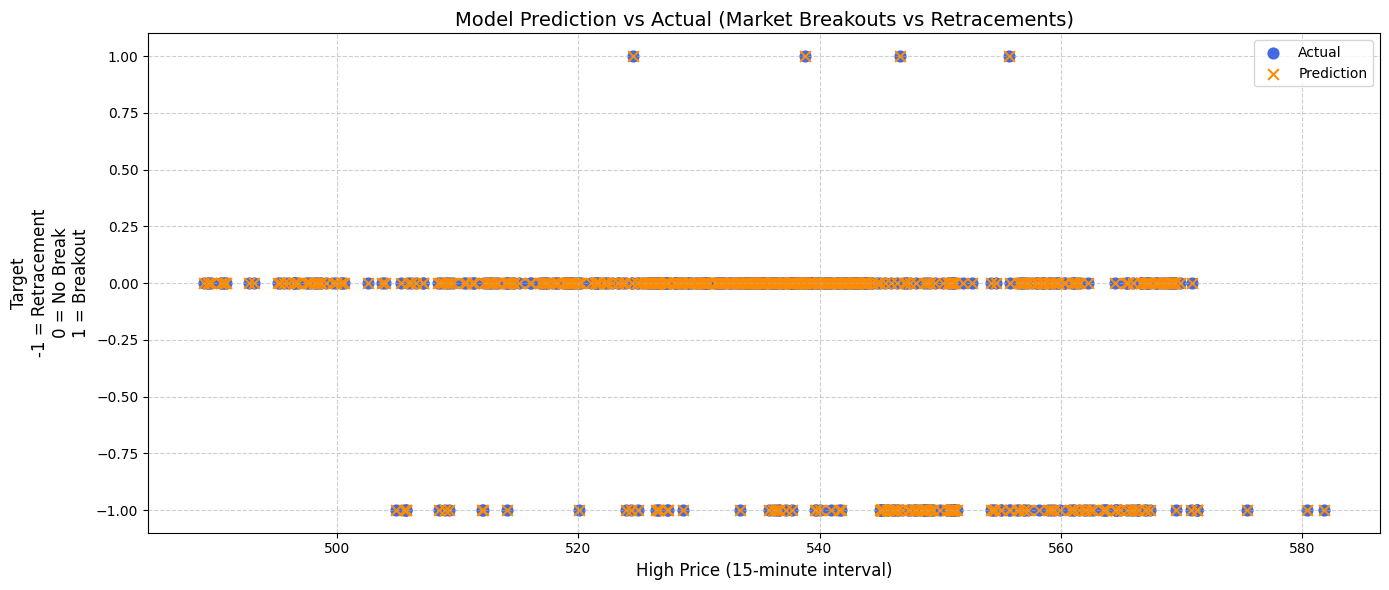

In [6]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Label encode the categorical columns 'liquidity_sweep' and 'retracement'
le_liquidity_sweep = LabelEncoder()
le_retracement = LabelEncoder()

merged_df['liquidity_sweep_encoded'] = le_liquidity_sweep.fit_transform(merged_df['liquidity_sweep'])
merged_df['retracement_encoded'] = le_retracement.fit_transform(merged_df['retracement'])

# Update features with encoded columns
features = [
    'open_x', 'high_x', 'low_x', 'close_x', 'volume_x',  # 15-minute data
    'London_High', 'London_Low', 'Prev_High', 'Prev_Low', # Engineered features from hourly data
    'liquidity_sweep_encoded', 'retracement_encoded'  # Encoded features
]

X = merged_df[features]
y = merged_df['target']


# Use SimpleImputer to fill missing values with the median
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Now split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.4, random_state=42)

# Train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict the target on the test set
y_pred = model.predict(X_test)

# Print classification report
print(classification_report(y_test, y_pred, digits=4))

# Plot the results
plt.figure(figsize=(14, 6))
plt.scatter(X_test[:, 1], y_test, label='Actual', color='royalblue', marker='o', s=60)  # Using 'high_x' index as example
plt.scatter(X_test[:, 1], y_pred, label='Prediction', color='darkorange', marker='x', s=60)  # Same

plt.title("Model Prediction vs Actual (Market Breakouts vs Retracements)", fontsize=14)
plt.xlabel("High Price (15-minute interval)", fontsize=12)
plt.ylabel("Target\n-1 = Retracement\n0 = No Break\n1 = Breakout", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
